## Computational Psycholinguistics A3

#### Name - Namrata Baliga
#### Roll Number - 2022101021

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from statsmodels.formula.api import ols
import statsmodels.api as sm
import nltk
import string
import seaborn as sns

In [16]:
gpt3_df = pd.read_csv('all_stories_gpt3.csv')
gpt3_df.rename(columns={'token': 'word'}, inplace=True)
gpt3_df['word_lower'] = gpt3_df['word'].astype(str).str.lower()

gpt3_df['neg_log_prob'] = -gpt3_df['logprob']
gpt3_df = gpt3_df.dropna(subset=['neg_log_prob'])
gpt3_grouped = gpt3_df.groupby('word_lower', as_index=False)['neg_log_prob'].mean()

mean_rt_per_word = pd.read_csv('mean_RT_per_word.tsv', sep='\t')
freq_clean = pd.read_csv('freq_clean.tsv', sep='\t')

merged = mean_rt_per_word.merge(freq_clean[['word_lower', 'frequency']], on='word_lower', how='inner')

merged = merged.merge(gpt3_grouped, on='word_lower', how='inner')

merged = merged.dropna(subset=['neg_log_prob', 'frequency', 'word_length', 'mean_RT'])
merged = merged.drop_duplicates(subset='word_lower')

In [17]:
X1 = merged[['frequency', 'word_length']]
X1 = sm.add_constant(X1)
model1 = sm.OLS(merged['mean_RT'], X1).fit()
merged['pred1'] = model1.predict(X1)

X2 = merged[['neg_log_prob', 'word_length']]
X2 = sm.add_constant(X2)
model2 = sm.OLS(merged['mean_RT'], X2).fit()
merged['pred2'] = model2.predict(X2)

print("Model 1 Summary (frequency + length):")
print(model1.summary())
print("\nModel 2 Summary (-logprob + length):")
print(model2.summary())

Model 1 Summary (frequency + length):
                            OLS Regression Results                            
Dep. Variable:                mean_RT   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                 -0.018
Method:                 Least Squares   F-statistic:                    0.3684
Date:                Tue, 17 Feb 2026   Prob (F-statistic):              0.693
Time:                        19:29:06   Log-Likelihood:                -352.56
No. Observations:                  73   AIC:                             711.1
Df Residuals:                      70   BIC:                             718.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const       

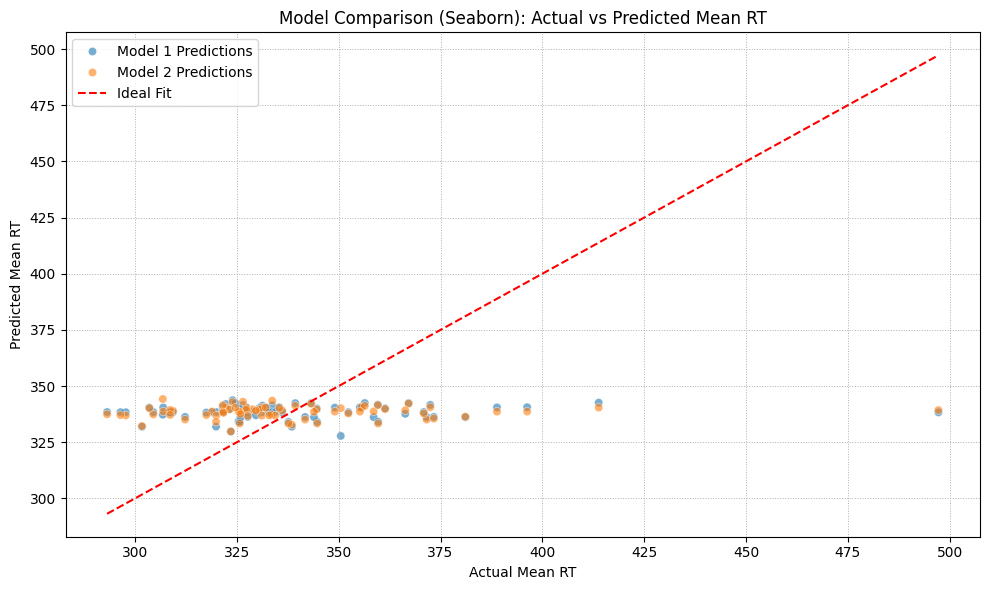

In [18]:
plot_df = merged[['mean_RT']].copy()
plot_df['Model 1 Predictions'] = merged['pred1']
plot_df['Model 2 Predictions'] = merged['pred2']

plot_long = plot_df.melt(id_vars='mean_RT', 
                         value_vars=['Model 1 Predictions', 'Model 2 Predictions'],
                         var_name='Model', value_name='Predicted RT')

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_long, x='mean_RT', y='Predicted RT', hue='Model', alpha=0.6)
plt.plot([merged['mean_RT'].min(), merged['mean_RT'].max()],
         [merged['mean_RT'].min(), merged['mean_RT'].max()],
         'r--', label='Ideal Fit')

plt.xlabel('Actual Mean RT')
plt.ylabel('Predicted Mean RT')
plt.title('Model Comparison (Seaborn): Actual vs Predicted Mean RT')
plt.legend()
plt.grid(True, linestyle=':', linewidth=0.7)
plt.tight_layout()
plt.show()

- Neither regression model achieved statistical significance, and both explained less than 1% of the variance in reading times. Thus, this analysis does not support the hypothesis that language model probabilities are better predictors of reading time than word frequency — at least not in this small sample.
- The R² and p-values are nearly identical for both models, suggesting neither predictor (frequency nor surprisal) has substantial explanatory power in isolation when predicting average reading time.
- The condition number is extremely high in Model 1 (4.67e+09), suggesting potential multicollinearity or numerical instability, likely due to the scale of raw frequencies. This isn't an issue in Model 2.

In [19]:
function_words = set([
    'a', 'an', 'the', 'in', 'on', 'at', 'by', 'to', 'of', 'for', 'with',
    'and', 'but', 'or', 'nor', 'so', 'yet', 'if', 'than', 'though', 'although',
    'because', 'while', 'as', 'until', 'before', 'after', 'when', 'where', 'how',
    'is', 'are', 'was', 'were', 'be', 'being', 'been', 'do', 'does', 'did', 'has', 'have', 'had',
    'he', 'she', 'it', 'they', 'we', 'you', 'i', 'me', 'him', 'her', 'us', 'them', 'my', 'your', 'our', 'their',
    'this', 'that', 'these', 'those',
    'whose', 'whom', 'which', 'what', 'who', 'each', 'either', 'neither', 'any', 'some', 'all', 'both', 
    'few', 'many', 'much', 'more', 'most', 'none', 'no', 'every', 'can', 'could', 'shall', 'should', 
    'will', 'would', 'may', 'might', 'must', 'ought', 'up', 'down', 'out', 'off', 'over', 'under', 
    'again', 'further', 'then', 'once'
])


merged['word_type'] = merged['word'].str.lower().apply(lambda w: 'function' if w in function_words else 'content')

merged.to_csv('merged_new.tsv', sep='\t', index=False)

content_df = merged[merged['word_type'] == 'content']
function_df = merged[merged['word_type'] == 'function']


In [20]:
X1 = sm.add_constant(content_df[['frequency', 'word_length']])
y1 = content_df['mean_RT']
model1 = sm.OLS(y1, X1).fit()

X2 = sm.add_constant(content_df[['neg_log_prob', 'word_length']])
model2 = sm.OLS(y1, X2).fit()

# Function word models
X3 = sm.add_constant(function_df[['frequency', 'word_length']])
y2 = function_df['mean_RT']
model3 = sm.OLS(y2, X3).fit()

X4 = sm.add_constant(function_df[['neg_log_prob', 'word_length']])
model4 = sm.OLS(y2, X4).fit()

# Store predictions back on copies to avoid SettingWithCopyWarning
content_df = content_df.copy()
content_df['pred1'] = model1.predict(X1)
content_df['pred2'] = model2.predict(X2)

function_df = function_df.copy()
function_df['pred3'] = model3.predict(X3)
function_df['pred4'] = model4.predict(X4)

print("Model 1 (Content - Freq):")
print(model1.summary())
print("\nModel 2 (Content - -logprob):")
print(model2.summary())
print("\nModel 3 (Function - Freq):")
print(model3.summary())
print("\nModel 4 (Function - -logprob):")
print(model4.summary())

Model 1 (Content - Freq):
                            OLS Regression Results                            
Dep. Variable:                mean_RT   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                 -0.041
Method:                 Least Squares   F-statistic:                    0.2001
Date:                Tue, 17 Feb 2026   Prob (F-statistic):              0.819
Time:                        19:29:06   Log-Likelihood:                -209.28
No. Observations:                  42   AIC:                             424.6
Df Residuals:                      39   BIC:                             429.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         342.4605  

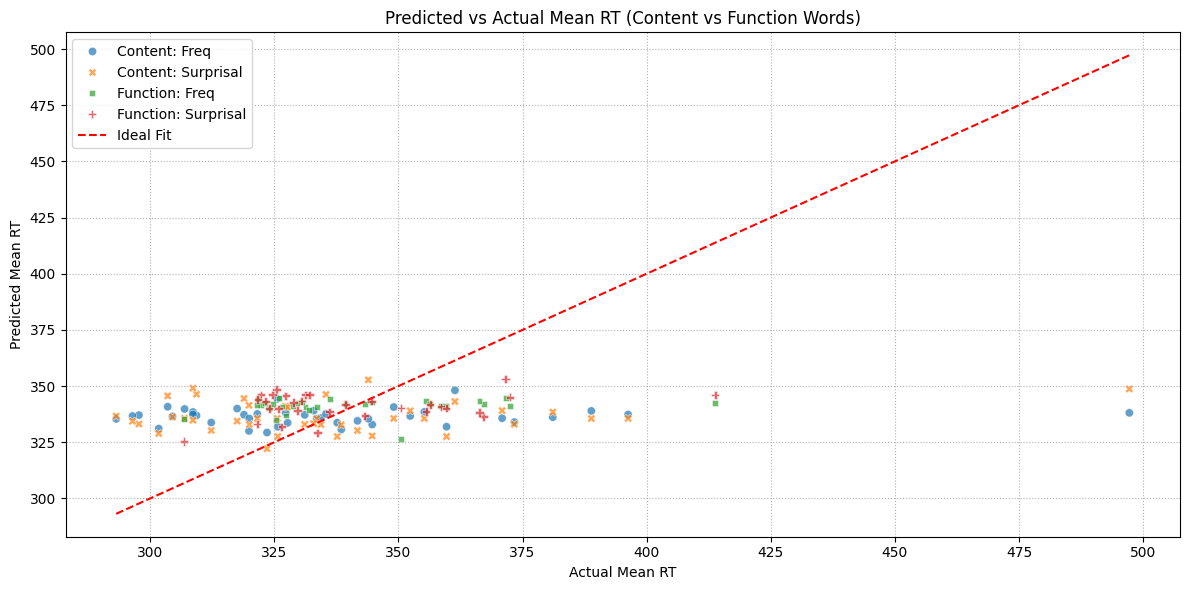

In [21]:
content_plot1 = content_df[['mean_RT', 'pred1']].copy()
content_plot1['Model'] = 'Content: Freq'
content_plot1['Predicted_RT'] = content_plot1['pred1']

content_plot2 = content_df[['mean_RT', 'pred2']].copy()
content_plot2['Model'] = 'Content: Surprisal'
content_plot2['Predicted_RT'] = content_plot2['pred2']

function_plot1 = function_df[['mean_RT', 'pred3']].copy()
function_plot1['Model'] = 'Function: Freq'
function_plot1['Predicted_RT'] = function_plot1['pred3']

function_plot2 = function_df[['mean_RT', 'pred4']].copy()
function_plot2['Model'] = 'Function: Surprisal'
function_plot2['Predicted_RT'] = function_plot2['pred4']

plot_df = pd.concat([content_plot1, content_plot2, function_plot1, function_plot2])

# Plot
plt.figure(figsize=(12, 6))
sns.scatterplot(data=plot_df, x='mean_RT', y='Predicted_RT', hue='Model', style='Model', alpha=0.7)
plt.plot([plot_df['mean_RT'].min(), plot_df['mean_RT'].max()],
         [plot_df['mean_RT'].min(), plot_df['mean_RT'].max()],
         'r--', label='Ideal Fit')

plt.title("Predicted vs Actual Mean RT (Content vs Function Words)")
plt.xlabel("Actual Mean RT")
plt.ylabel("Predicted Mean RT")
plt.legend()
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()

### Content Words

- Model 2 (surprisal) slightly outperforms Model 1 (frequency) in explaining mean reading time (lower AIC and higher R²).

- neg_log_prob has a positive coefficient, suggesting more surprising content words are read more slowly — in line with psycholinguistic theory — but not significant here.

- This suggests that for content words, predictability (surprisal) from a language model might be a more informative predictor than raw frequency.

- None of the predictors are statistically significant, but this may be due to sample size or noise in the data.

### Function Words

- Model 4 (surprisal) also outperforms the frequency model (Model 3) with higher R² and lower AIC.
- The coefficient for surprisal is negative, suggesting that less predictable function words are read faster — which may reflect habitual, automated processing of these words.

- Content words show a slight trend where surprisal predicts slower reading.
- Function words show more variability, but surprisal doesn’t align with expectations.

------------

- The results offer preliminary support for the hypothesis that content and function words are processed differently. Across both word types, regression models incorporating language model surprisal provided slightly better fits than those based on word frequency. This trend was more evident for function words, where surprisal explained approximately 6.9% of the variance in mean reading time, compared to just 2.7% for frequency.
- Although none of the predictors reached statistical significance, the overall pattern suggests that contextual predictability—as captured by language model probabilities—may be a more informative predictor of reading time than raw frequency, particularly for content words that carry greater semantic load. In contrast, function words may be processed more automatically and governed by different cognitive mechanisms, potentially resulting in weaker or more variable relationships with predictability-based metrics.

